In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../data/processed/final_dataset_with_features.csv')

Kod `src\data\create_feature.py` realizuje proces tworzenia cech, które opisują artykuły. Wśród tych zmiennych są:
- *POS tagging*, czyli opiywanie części mowy oraz zwracanie gęstości ich występowania w całym tekście. Uwzględniono zaimki we wszystkich osobach (`pronoun_1st_density`, `pronoun_2nd_density`, `pronoun_3rd_density`), przymiotniki (`adj_density`) oraz spójniki (`conj_density`),
- gęstość cytowań (zmienna `quote_density`),
- wydobywanie encji oraz wyznaczanie gęstości ich występowania. Badamy jak często w artykule jest mowa o konkretnych osobach (`person_density`), organizacjach (`org_density`), obszarach geograficznych (`gpe_density`) oraz liczb (`cardinal_density`).

Dodatkowo z użyciem kodu `src\data\emotion_extraction.py` wydobywamy emocje na podstawie tekstów. Stosujemy do tego modelu <a href="https://huggingface.co/j-hartmann/emotion-english-distilroberta-base">j-hartmann/emotion-english-distilroberta-base</a>, który klasyfikuje input na 6 podstawowych emocji: złość, obrzydzenie, strach, szczęście, smutek, zaskoczenie. Dodano również techniczną klasę neutral. Kod zwraca szacowane prawdopodobieństwo dla każdej z klas na podstawie pierwszego chunku tekstu (context window tego modelu wynosi ok. 512 tokenów) - założenie jest takie, że to własnie na początku tekstu mogą występować jakieś clickbaity lub pobudzanie emocji u czytającego. Do tego wyliczamy entropię emocji (`emotion_entropy`), aby zmierzyć zróżnicowanie i stabilność profilu emocjonalnego całego artykułu. 

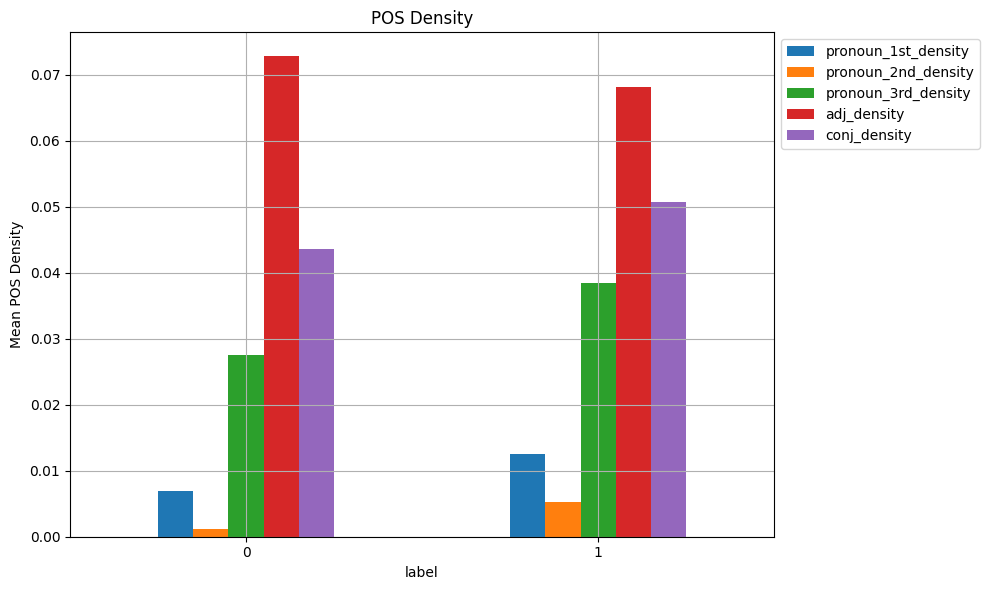

In [3]:
features = [
    'pronoun_1st_density', 
    'pronoun_2nd_density', 
    'pronoun_3rd_density', 
    'adj_density', 
    'conj_density'
]

data.groupby('label')[features].mean().plot.bar(
    title='POS Density',
    ylabel='Mean POS Density',
    figsize=(10, 6),
    rot=0,
    grid=True
)

plt.legend(bbox_to_anchor=(1, 1), loc='upper left') 
plt.tight_layout()
plt.show()

Zauważamy pierwsze różnice na poziomie stosowanych części mowy - artykuły o mniejszej wiarygodności częściej używają w komunikacji drugiej osobę (ty, wy). Wyraźnie częściej stosowana jest również trzecia osoba.

Ze względu na to, że w obserwacjach klasy 0 mamy również krótkie formy (tweety), zobaczmy jak z wyłączeniem tej grupy wygląda rozkład części mowy:

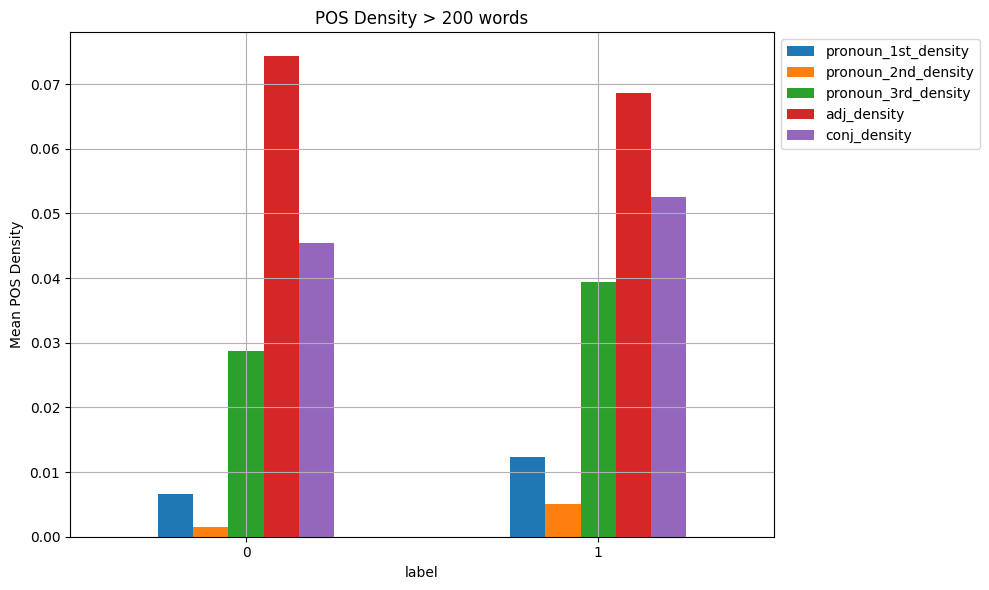

In [4]:
df_filtered = data[data['text'].str.split().str.len() >= 200]

features = [
    'pronoun_1st_density', 
    'pronoun_2nd_density', 
    'pronoun_3rd_density', 
    'adj_density', 
    'conj_density'
]

df_filtered.groupby('label')[features].mean().plot.bar(
    title='POS Density > 200 words',
    ylabel='Mean POS Density',
    figsize=(10, 6),
    rot=0,
    grid=True
)

plt.legend(bbox_to_anchor=(1, 1), loc='upper left') 
plt.tight_layout()
plt.show()

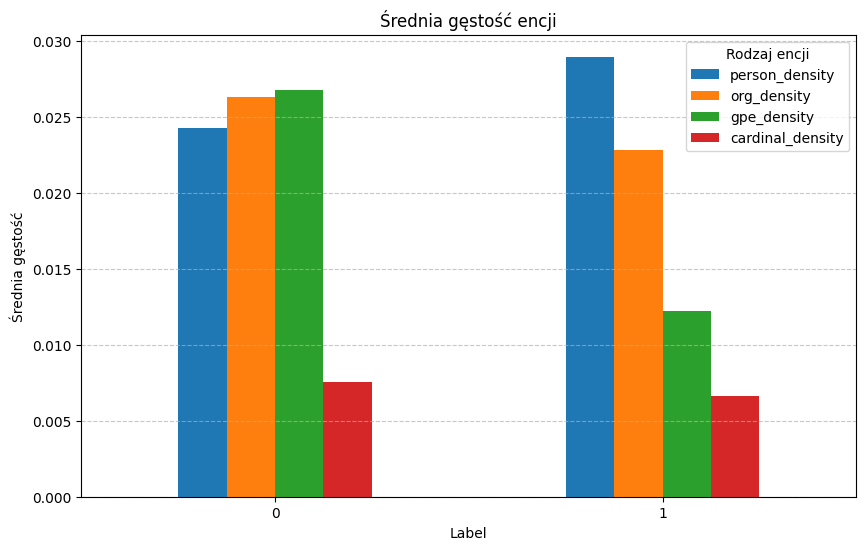

In [5]:
features_to_plot = ['person_density', 'org_density', 'gpe_density', 'cardinal_density']

df_grouped = data.groupby('label')[features_to_plot].mean()

ax = df_grouped.plot(
    kind='bar', 
    figsize=(10, 6), 
    title='Średnia gęstość encji'
)

plt.ylabel('Średnia gęstość')
plt.xlabel('Label')
plt.xticks(rotation=0) 
plt.legend(title='Rodzaj encji')
plt.grid(axis='y', linestyle='--', alpha=0.7) 

# Wyświetlenie
plt.show()

Gęstość encji zdecydowanie różnicuje obie populacje - w artykułach rzetelnych organizacje, osoby oraz krainy geograficzne są wspominane z podobną, wysoką częstotliwością. Natomiast w artykułach niewiarygodnych wspominano znacząco rzadziej o organizacjach oraz krainach geograficznych.

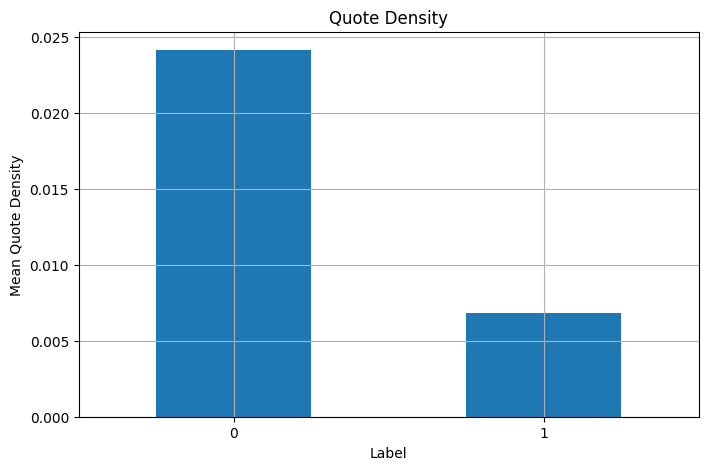

In [6]:
data.groupby("label")["quote_density"].mean().plot.bar(
    title="Quote Density",
    ylabel="Mean Quote Density",
    xlabel="Label",
    figsize=(8, 5),
    rot=0,
    grid=True
)
plt.show()


Jeszcze większe różnice występują w kwesti cytowań - średnio w artykułach z wiarygodnych/potwierdzonych źródeł jest 4 razy więcej cytowań.

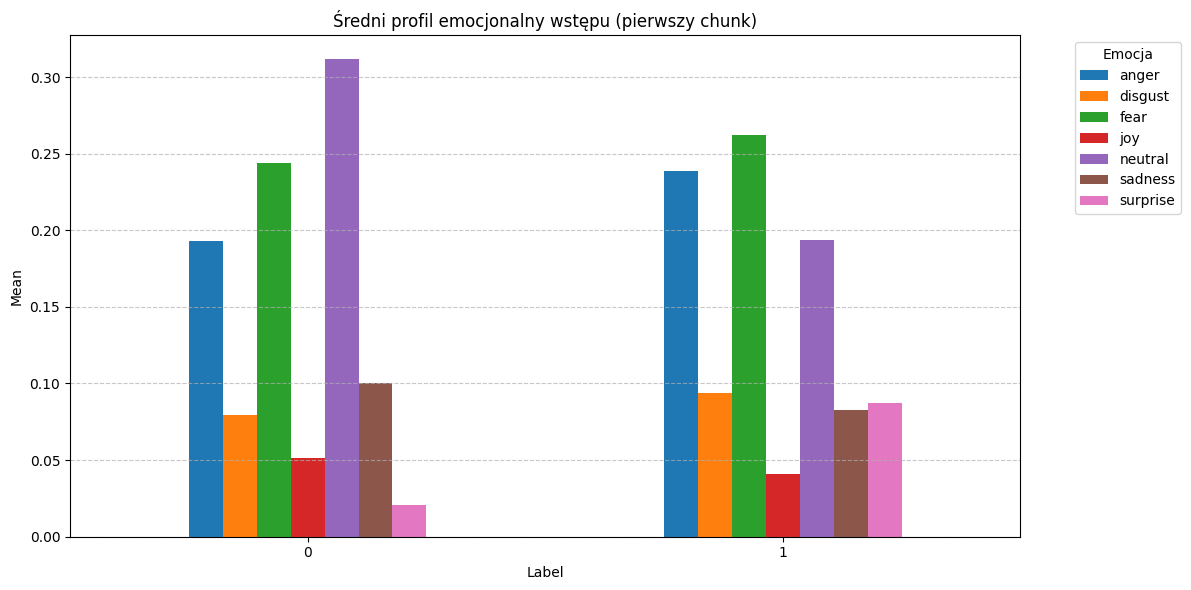

In [7]:
emotion_features = [
    'first_chunk_prob_anger', 
    'first_chunk_prob_disgust', 
    'first_chunk_prob_fear', 
    'first_chunk_prob_joy', 
    'first_chunk_prob_neutral', 
    'first_chunk_prob_sadness', 
    'first_chunk_prob_surprise'
]

df_emotions_grouped = data.groupby('label')[emotion_features].mean()

df_emotions_grouped.columns = [col.replace('first_chunk_prob_', '') for col in df_emotions_grouped.columns]

ax = df_emotions_grouped.plot(
    kind='bar', 
    figsize=(12, 6), 
    title='Średni profil emocjonalny wstępu (pierwszy chunk)'
)

plt.ylabel('Mean')
plt.xlabel('Label')
plt.xticks(rotation=0)
plt.legend(title='Emocja', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() 
plt.show()

Wstępy do tekstów z rzetelnych źródeł zostały częściej oznaczano jako neutralne (*neutral*), rozkład pozostałych emocji jest porównywalny dla obu klas. Prawdopodobnie zastosowanie bardziej zaawansowanych oraz nowszych modeli językowych dostarczyłoby dokładniejszych informacji. 

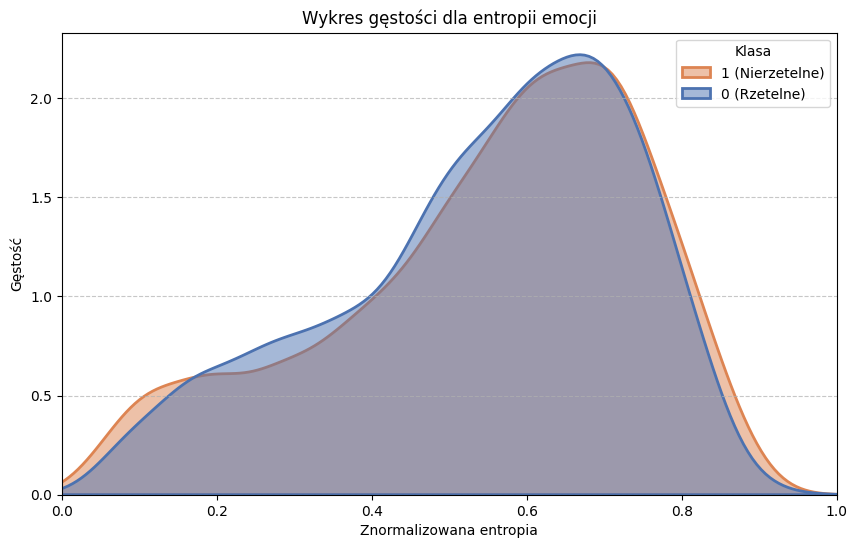

In [8]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=data, 
    x='emotion_entropy', 
    hue='label', 
    fill=True,          
    common_norm=False,   
    palette=['#4C72B0', '#DD8452'], 
    alpha=0.5,          
    linewidth=2
)

plt.title('Wykres gęstości dla entropii emocji')
plt.xlabel('Znormalizowana entropia')
plt.ylabel('Gęstość')

plt.xlim(0, 1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Klasa', labels=['1 (Nierzetelne)', '0 (Rzetelne)'])

plt.show()

Rozkłady entropii emocji dla obu klas niemal całkowicie się pokrywają, co udowadnia, że uśredniona entropia dla całego artykułu nie pozwala skutecznie odróżnić fake newsów od rzetelnych tekstów. 